# Benchmarking of ML methods to analyze a dataset on the Estimation of obesity habits

### Short description of the dataset

This paper contains data for the estimation of obesity levels in people from the countries of Mexico,
Peru and Colombia, with ages between 14 and 61 and diverse eating habits and physical condition as
mentioned by [1].

Data was collected using a web platform with a survey (see Table 1) where anon-
ymous users answered each question, then the information was processed obtaining 17 attributes and
2111 records, after a balancing process described in Figs. 1 and 2.

### The attributes related with eating habits are: 

- Frequent consumption of high caloric food (FAVC),
- Frequency of consumption of vegetables (FCVC), 
- Number of main meals (NCP), 
- Consumption of food between meals (CAEC),
- Consumption of water daily (CH20),
- Consumption of alcohol (CALC). 

### The attributes related with the physical condition are: 

- Calories consumption monitoring (SCC), 
- Physical activity frequency (FAF), 
- Time using technology devices (TUE),
- Transportation used (MTRANS)

### other variables obtained were: 
- Gender, 
- Age,
- Height 
- Weight.

Finally, all data was labeled and the class variable NObesity was created with the
values of: 
- Insuf cient Weight, Normal Weight, Overweight Level I, Overweight Level II, Obesity Type I,
Obesity Type II and Obesity Type III, based on Equation (1) and information from WHO and Mexican
Normativity.

 The data contains numerical data and continous data, so it can be used for analysis based
on algorithms of classi cation, prediction, segmentation and association. Data is available in CSV
format and ARFF format to be used with the Weka tool.

# I - Data preprocessing and feature engineering

In [228]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sklearn
import scipy
import seaborn as sns

In [229]:
df = pd.read_csv("data/ObesityDataSet_raw_and_data_sinthetic.csv")
df

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.000000,1.620000,64.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,0.000000,1.000000,no,Public_Transportation,Normal_Weight
1,Female,21.000000,1.520000,56.000000,yes,no,3.0,3.0,Sometimes,yes,3.000000,yes,3.000000,0.000000,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.000000,1.800000,77.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,2.000000,1.000000,Frequently,Public_Transportation,Normal_Weight
3,Male,27.000000,1.800000,87.000000,no,no,3.0,3.0,Sometimes,no,2.000000,no,2.000000,0.000000,Frequently,Walking,Overweight_Level_I
4,Male,22.000000,1.780000,89.800000,no,no,2.0,1.0,Sometimes,no,2.000000,no,0.000000,0.000000,Sometimes,Public_Transportation,Overweight_Level_II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,Female,20.976842,1.710730,131.408528,yes,yes,3.0,3.0,Sometimes,no,1.728139,no,1.676269,0.906247,Sometimes,Public_Transportation,Obesity_Type_III
2107,Female,21.982942,1.748584,133.742943,yes,yes,3.0,3.0,Sometimes,no,2.005130,no,1.341390,0.599270,Sometimes,Public_Transportation,Obesity_Type_III
2108,Female,22.524036,1.752206,133.689352,yes,yes,3.0,3.0,Sometimes,no,2.054193,no,1.414209,0.646288,Sometimes,Public_Transportation,Obesity_Type_III
2109,Female,24.361936,1.739450,133.346641,yes,yes,3.0,3.0,Sometimes,no,2.852339,no,1.139107,0.586035,Sometimes,Public_Transportation,Obesity_Type_III


### Basic statistics about the data

In [230]:
df.head(5)

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [231]:
n, p =df.shape
n, p

(2111, 17)

In [232]:
## Rajout de la colonne IMC_index puis mise à jour des classes de poids

df["IMC_index"] = df["Weight"]/(df["Height"]**2)

def categorize_weight(row):
    weight_index = row['Weight'] / (row['Height'] ** 2)
    if weight_index < 18.5:
        return 'Underweight'
    elif 18.5 <= weight_index < 25:
        return 'Normal'
    elif 25 <= weight_index < 30:
        return 'Overweight'
    elif 30 <= weight_index < 35:
        return 'Obesity I'
    elif 35 <= weight_index < 40:
        return 'Obesity II'
    else:
        return 'Obesity III'
    
df["Weight_class"] = df.apply(categorize_weight, axis=1)
weight_order = ["Underweight", "Normal", "Overweight", "Obesity I", "Obesity II", "Obesity III"]
df["Weight_class"] = pd.Categorical(df["Weight_class"], categories=weight_order, ordered=True)

## Train / test separation

In [233]:
def split_train_test(data : pd.DataFrame, test_ratio, y):
    shuffle = np.random.permutation(n)
    separator = int(test_ratio*n)
    tr_indices = shuffle[:separator]
    te_indices = shuffle[separator:]

    return data.iloc[tr_indices], data.iloc[te_indices], y[tr_indices], y[te_indices]

In [234]:
tr_data, te_data, y_tr, y_te = split_train_test(df, 0.8, df["Weight_class"])
tr_data.head(10)

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad,IMC_index,Weight_class
80,Female,19.000000,1.630000,58.000000,no,no,3.000000,3.000000,Sometimes,no,2.000000,yes,0.000000,0.000000,no,Public_Transportation,Normal_Weight,21.829952,Normal
1483,Female,37.613378,1.516007,77.033049,yes,yes,2.000000,2.880794,Sometimes,no,1.618370,no,0.120165,0.000000,Sometimes,Automobile,Obesity_Type_I,33.517736,Obesity I
1284,Female,28.770039,1.580858,79.713492,yes,yes,2.000000,1.000000,Sometimes,no,2.000000,no,0.005405,0.000000,no,Public_Transportation,Obesity_Type_I,31.896726,Obesity I
1439,Female,40.654155,1.529060,79.760922,yes,yes,2.000000,3.000000,Sometimes,no,1.000000,no,0.000000,0.000000,Sometimes,Automobile,Obesity_Type_I,34.114665,Obesity I
713,Female,20.850119,1.524926,42.000000,no,yes,2.866383,1.226342,Frequently,no,1.000000,no,0.144950,0.000000,Sometimes,Public_Transportation,Insufficient_Weight,18.061414,Underweight
1176,Female,18.741188,1.556789,71.788181,yes,no,3.000000,3.129155,Sometimes,no,2.000000,no,1.634134,1.000000,no,Public_Transportation,Overweight_Level_II,29.620572,Overweight
1630,Male,30.403205,1.696365,102.815983,yes,yes,2.791660,2.132290,Sometimes,no,1.254589,no,0.652736,1.040713,no,Public_Transportation,Obesity_Type_II,35.729096,Obesity II
2083,Female,24.469756,1.663341,113.077187,yes,yes,3.000000,3.000000,Sometimes,no,2.632224,no,0.300964,0.269560,Sometimes,Public_Transportation,Obesity_Type_III,40.870732,Obesity III
1343,Male,18.000000,1.783906,109.207614,yes,yes,2.000000,1.867836,Sometimes,no,2.438398,no,1.000000,0.802305,no,Public_Transportation,Obesity_Type_I,34.316974,Obesity I
821,Female,32.501143,1.675979,74.959747,yes,yes,2.291846,1.555557,Sometimes,no,1.000000,no,0.000000,0.388271,Sometimes,Automobile,Overweight_Level_I,26.686460,Overweight


## Pipeline : Categorigal & numerical variables transformation

In [235]:
numerical_variables = ["Age", "FCVC", "NCP", "CH2O", "FAF", "TUE"]
categorical_variables = ["Gender", "family_history_with_overweight", "FAVC", "CAEC", "SMOKE", "SCC", "CALC", "MTRANS"]
used_variables = ["Age", "FCVC", "NCP", "CH2O", "FAF", "TUE","Gender", "family_history_with_overweight", "FAVC", "CAEC", "SMOKE", "SCC", "CALC", "MTRANS"]
print(df[categorical_variables])
print(weight_order)

      Gender family_history_with_overweight FAVC       CAEC SMOKE  SCC  \
0     Female                            yes   no  Sometimes    no   no   
1     Female                            yes   no  Sometimes   yes  yes   
2       Male                            yes   no  Sometimes    no   no   
3       Male                             no   no  Sometimes    no   no   
4       Male                             no   no  Sometimes    no   no   
...      ...                            ...  ...        ...   ...  ...   
2106  Female                            yes  yes  Sometimes    no   no   
2107  Female                            yes  yes  Sometimes    no   no   
2108  Female                            yes  yes  Sometimes    no   no   
2109  Female                            yes  yes  Sometimes    no   no   
2110  Female                            yes  yes  Sometimes    no   no   

            CALC                 MTRANS  
0             no  Public_Transportation  
1      Sometimes  Public_Tr

In [236]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

In [237]:
num_pipeline = Pipeline([("imputer", SimpleImputer(strategy='median')),
                        ("std_scaler", StandardScaler())])
full_pipeline = ColumnTransformer([("num", num_pipeline, numerical_variables),
                                   ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), categorical_variables)], verbose_feature_names_out= False)
full_pipeline.set_output(transform="pandas")
tr_data = full_pipeline.fit_transform(tr_data)
te_data = full_pipeline.transform(te_data)
full_data = full_pipeline.transform(df)

## Visuals and statistics about this dataset

In [238]:
print( " Dataset description : ")
df.describe().T

 Dataset description : 


,count,mean,std,min,25%,50%,75%,max
Age,2111.0,24.312600,6.345968,14.000000,19.947192,22.777890,26.000000,61.000000
Height,2111.0,1.701677,0.093305,1.450000,1.630000,1.700499,1.768464,1.980000
Weight,2111.0,86.586058,26.191172,39.000000,65.473343,83.000000,107.430682,173.000000
FCVC,2111.0,2.419043,0.533927,1.000000,2.000000,2.385502,3.000000,3.000000
NCP,2111.0,2.685628,0.778039,1.000000,2.658738,3.000000,3.000000,4.000000
CH2O,2111.0,2.008011,0.612953,1.000000,1.584812,2.000000,2.477420,3.000000
FAF,2111.0,1.010298,0.850592,0.000000,0.124505,1.000000,1.666678,3.000000
TUE,2111.0,0.657866,0.608927,0.000000,0.000000,0.625350,1.000000,2.000000
IMC_index,2111.0,29.700159,8.011337,12.998685,24.325802,28.719089,36.016501,50.811753


In [239]:
## Non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   Gender                          2111 non-null   object  
 1   Age                             2111 non-null   float64 
 2   Height                          2111 non-null   float64 
 3   Weight                          2111 non-null   float64 
 4   family_history_with_overweight  2111 non-null   object  
 5   FAVC                            2111 non-null   object  
 6   FCVC                            2111 non-null   float64 
 7   NCP                             2111 non-null   float64 
 8   CAEC                            2111 non-null   object  
 9   SMOKE                           2111 non-null   object  
 10  CH2O                            2111 non-null   float64 
 11  SCC                             2111 non-null   object  
 12  FAF                 

<Axes: >

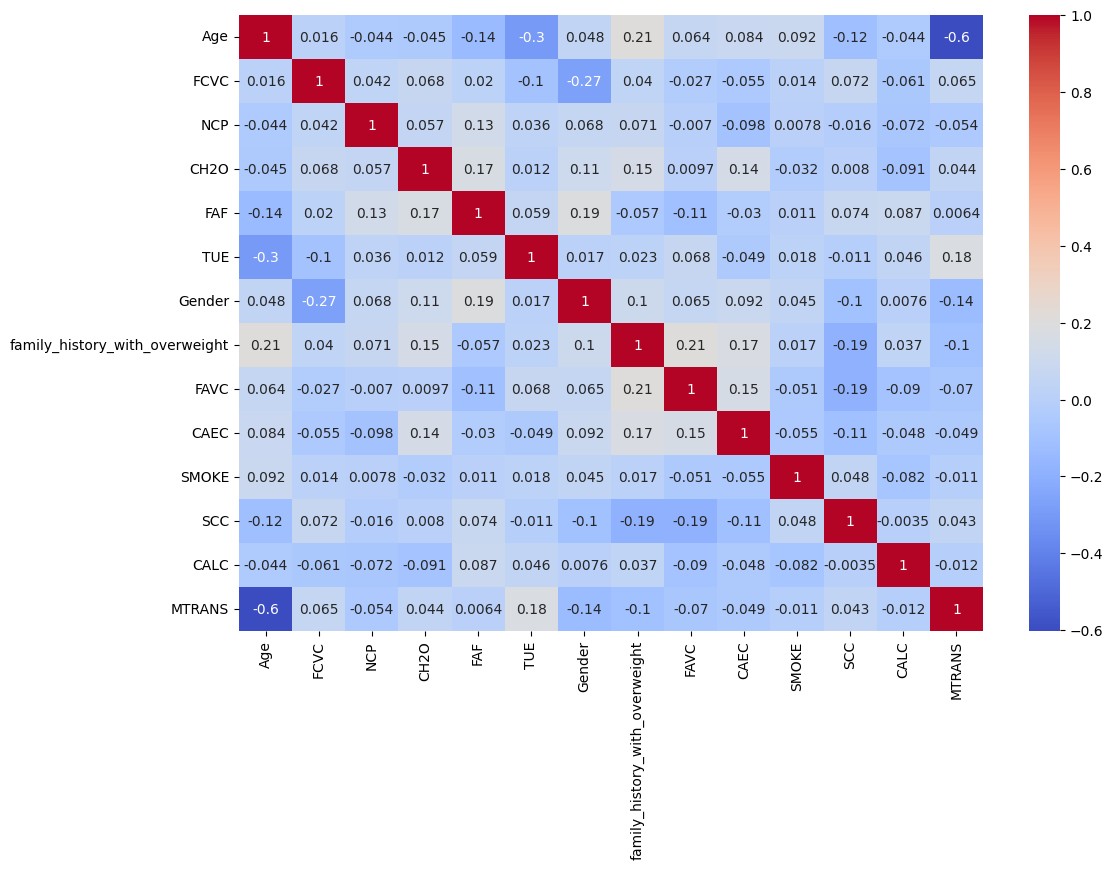

In [240]:
## Correlation Heatmap
transformed_df = pd.DataFrame(full_data, columns = full_pipeline.get_feature_names_out())
plt.figure(figsize=(12, 8))
sns.heatmap(transformed_df.corr(), annot = True, cmap = "coolwarm")

À la vue de ces premiers résultats, les variables les plus coréllées positivement avec IMC_index sont :
- Weight ( par définition )
- Family history with overweight
- NObeyesdad
- CAEC
- FAVC
- FCVC

Les variables corrélées négativement sont : 
- FAF
- CALC

Les variables quasi indépendantes de IMC_index sont : 
- NCP
- CH20
- TUE
- Gender
- SMOKE
- MTRANS

In [241]:
def create_displot(df, column):
    sns.displot(data = df, x = column, hue = "Weight_class", kde = True)

def create_hisplot(df, column, hue, kde = True):
    sns.histplot(data = df, x = column, hue = hue, kde = kde)

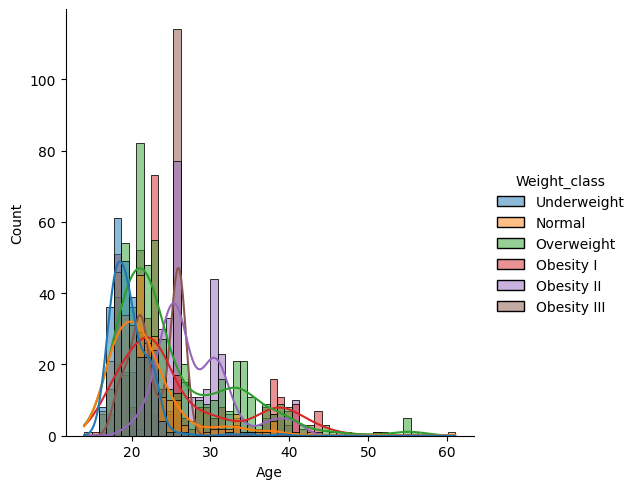

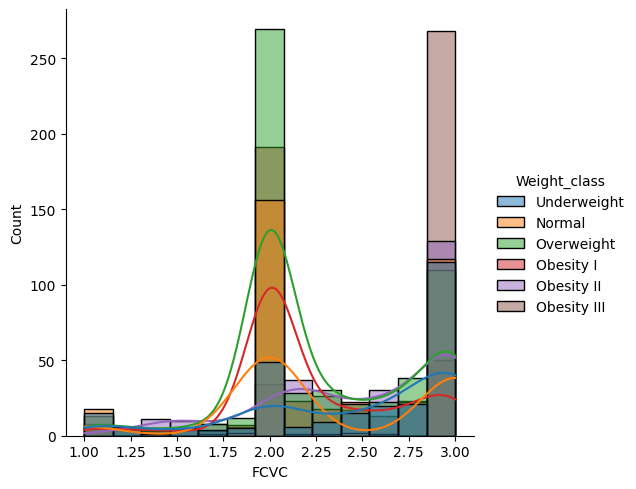

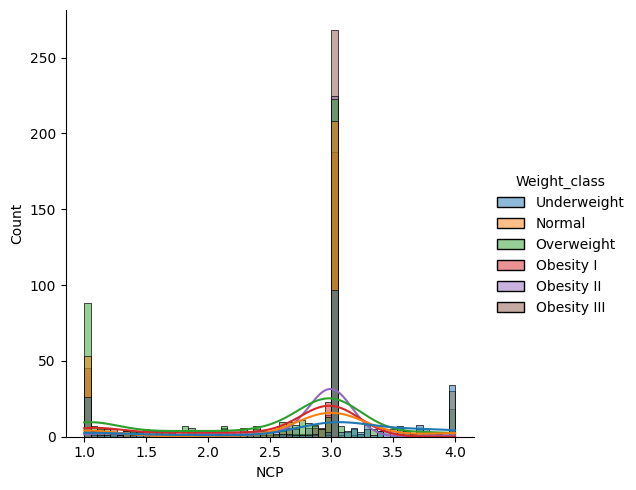

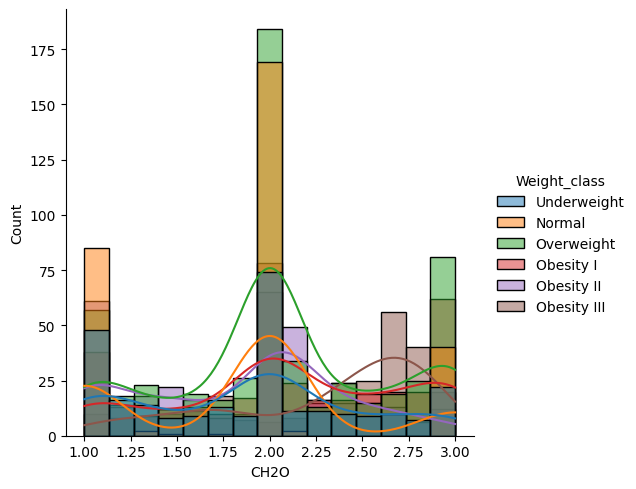

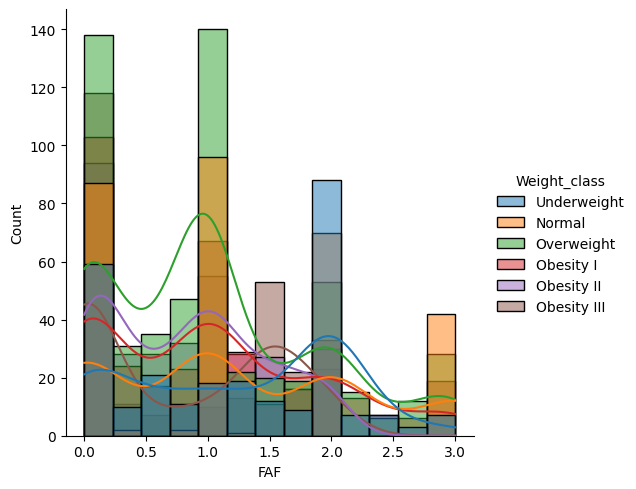

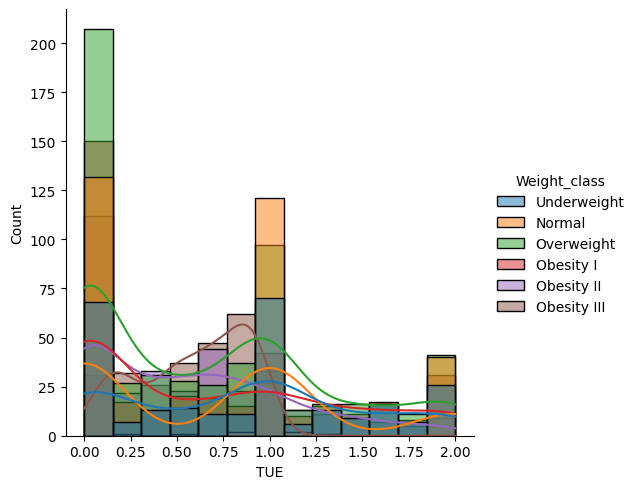

In [242]:
for i in numerical_variables:
    create_displot(df, i)

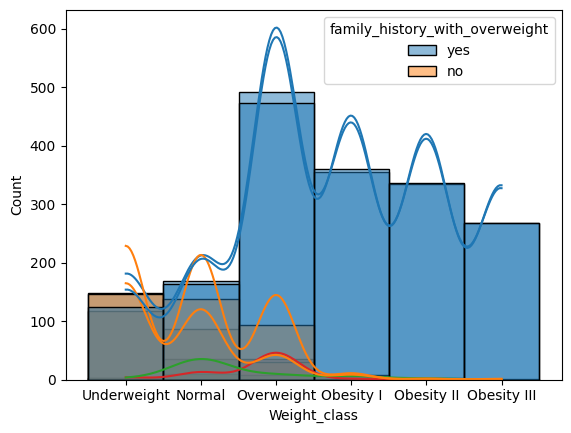

In [243]:
create_hisplot(df, column="Weight_class", hue = "CAEC")
create_hisplot(df, column="Weight_class", hue = "family_history_with_overweight")

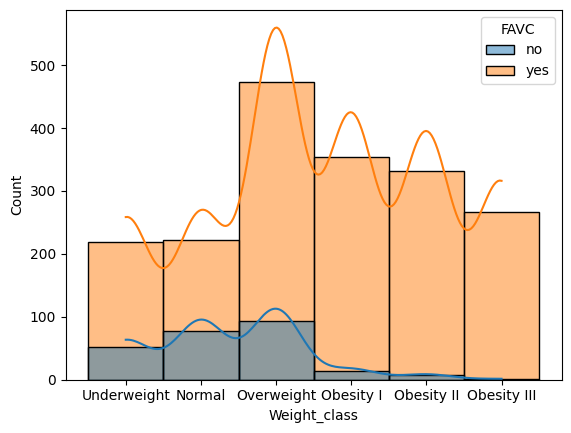

In [244]:
create_hisplot(df, column="Weight_class", hue = "FAVC")

## II - ML Approaches comparisons

For each method we will work sequentally : 
- First, we will train a dummy classifier on the training data, evaluating it on the test set
- Then we will optimize the hyperparameters through N = 10 fold cross-validation
- Check the utility of Bagging for the present model
- Compute the scores : accuracy, f1-score
- Plot local and global explainability features with SHAP


- After these analysis for each model of classifier we will select the best one for the most relevant metric to our use case and will fine-tune it to get the best performance out of it

## SVM

## Decision Trees

In [245]:
## Dummy classifier

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

dt = DecisionTreeClassifier(criterion='entropy', splitter='best', max_depth=10)
dt.fit(tr_data, y_tr)
y_pred = dt.predict(te_data)

In [246]:
score = cross_val_score(DecisionTreeClassifier(criterion='entropy'), full_data, df["Weight_class"], cv = 10, scoring="balanced_accuracy")
mean = score.mean()
var = score.std()
print("L'accuracy pour les tree classifiers entraînés sur 10 folds vaut : ", mean, " +- ", var)

score = cross_val_score(DecisionTreeClassifier(criterion='entropy'), full_data, df["Weight_class"], cv = 10, scoring="f1_macro")
mean = score.mean()
var = score.std()
print("Le f1-score pour les tree classifiers entraînés sur 10 folds vaut : ", mean, " +- ", var)


L'accuracy pour les tree classifiers entraînés sur 10 folds vaut :  0.7310817878503637  +-  0.10444646276865918
Le f1-score pour les tree classifiers entraînés sur 10 folds vaut :  0.7328692084078108  +-  0.10565437103559805


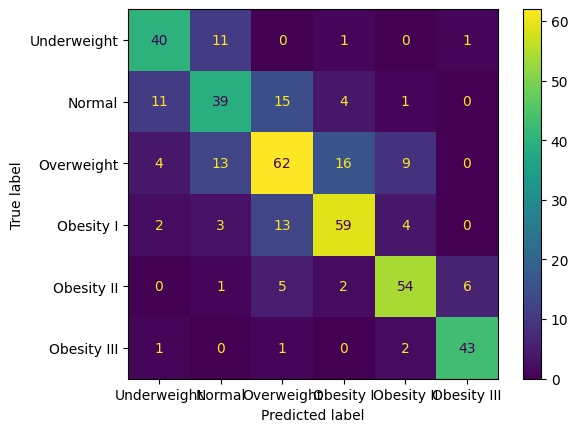

In [247]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_te, y_pred, labels= weight_order)
display = ConfusionMatrixDisplay(cm, display_labels= weight_order)
display.plot()

#### En conclusion pour les Decision Tree, ces classifieurs atteignent une précision correcte sur le dataset mais qui représente une borne inférieure pour le traitement du dataset par Random Forest et Gradient Boosting

## Random Forests

In [248]:
from sklearn.ensemble import RandomForestClassifier
n_estimators = np.arange(1, 80, 2)
depth = 20
leaf_size = 3
max_depth = [3, 5, 8, 10, 15, 20]

In [249]:
rf = RandomForestClassifier(n_estimators=100, max_depth=10)
rf.fit(tr_data, y_tr)
y_pred = rf.predict(te_data)

In [250]:
score = cross_val_score(RandomForestClassifier(n_estimators=100, max_depth=10), full_data, df["Weight_class"], cv = 10, scoring="balanced_accuracy")
mean = score.mean()
var = score.std()
print("L'accuracy pour le random forest classifier entraîné sur 10 folds vaut : ", mean, " +- ", var)

score = cross_val_score(RandomForestClassifier(n_estimators=100, max_depth=10), full_data, df["Weight_class"], cv = 10, scoring="f1_macro")
mean = score.mean()
var = score.std()
print("Le f1-score pour le random forest classifier entraîné sur 10 folds vaut : ", mean, " +- ", var)

L'accuracy pour le random forest classifier entraîné sur 10 folds vaut :  0.7900575000394402  +-  0.1314455494126172
Le f1-score pour le random forest classifier entraîné sur 10 folds vaut :  0.7978393917233936  +-  0.13373388265054287


#### Sans optimisation des hyperparamètres, le modèle random forest a une précision déjà 7 pts plus grande que les Decision tree seuls

In [251]:
def parameter_optim_forest(depth, leaf_size, df, n_estimators, n_iterations=10):
    moyenne = []
    variance = []
    NUM_ESTIMATOR = []
    memory = []

    for n in range(n_iterations):
        results = np.zeros(4)
        for n_estimator in range(n_estimators.shape[0]):
            X_tr, X_te, y_tr, y_te = split_train_test(df, 0.8, df["Weight_class"])
            X_tr = full_pipeline.fit_transform(X_tr)
            rf = RandomForestClassifier(criterion='entropy', max_depth=depth, min_samples_leaf=leaf_size, n_estimators=n_estimators[n_estimator])
            val_score = cross_val_score(rf, X_tr, y_tr, cv = 10)
            score = val_score.mean()
            var = val_score.std()
            if score > results[0]:
                results[0] = score
                results[1] = n_estimators[n_estimator]
                results[2] = var
            memory.append(score)

        
        score = results[0]
        moyenne.append(score)
        variance.append(var)
        NUM_ESTIMATOR.append(results[1])

    MEAN = np.mean(moyenne)
    STD = np.mean(variance)
    
    return MEAN, STD, NUM_ESTIMATOR, memory, variance

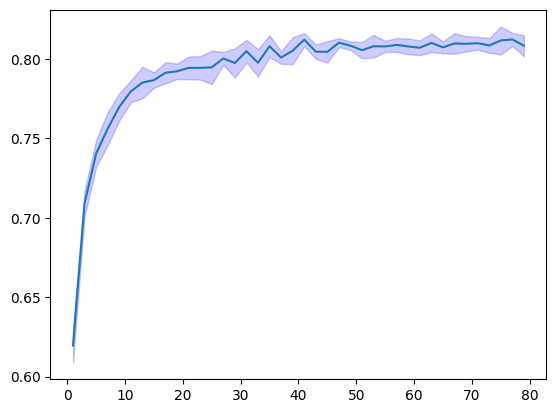

In [252]:
#MEAN, STD, NUM_ESTIMATOR, memory, variance = parameter_optim_forest(depth, leaf_size, df, n_estimators, n_iterations=5)
memory = np.array(memory).reshape(5, len(n_estimators)) # (10, 40)
mean_curve = memory.mean(axis = 0)
std_curve = memory.std(axis = 0) # dispersion entre les 5 répétitions

N = np.arange(40)
plt.plot(n_estimators, mean_curve)
plt.fill_between(n_estimators, mean_curve - std_curve, mean_curve + std_curve, color = 'blue', alpha = .2)


## Feature importance with Random forests

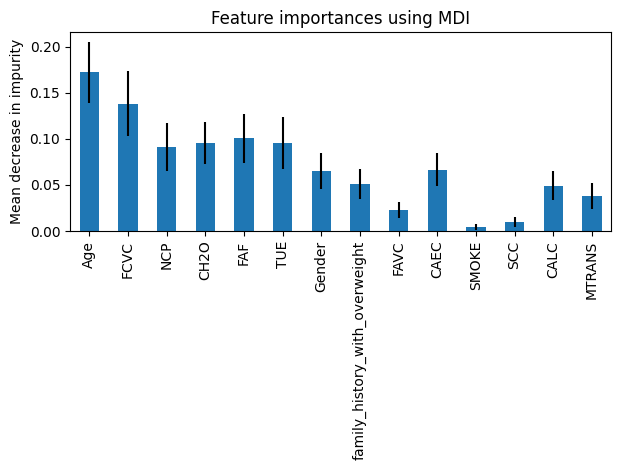

In [253]:
importances = rf.feature_importances_
std = np.std([tree.feature_importances_ for tree in rf.estimators_], axis=0)
forest_importances = pd.Series(importances, index=used_variables)

fig, ax = plt.subplots()
forest_importances.plot.bar(yerr=std, ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()


## Gradient Boosting

### Dummy classifier

In [254]:
from xgboost import XGBClassifier
import xgboost as xgb

In [255]:
dtrain = xgb.DMatrix(tr_data, label = y_tr.cat.codes)
dtest = xgb.DMatrix(te_data, label = y_te.cat.codes)

param = {
    'max_depth': 3,  # the maximum depth of each tree
    'eta': 0.3,  # Learning rate, the training step for each iteration
    'objective': 'multi:softprob',  # Evaluation metrics for training
    'num_class': 6, # Number of classes in this dataset
    'eval_metric': 'mlogloss' # Evaluation metrics for validation data
}
num_round = 20  # the number of training iterations

model = xgb.train(param, dtrain, num_round)
preds = model.predict(dtest)
predictions = np.asarray([np.argmax(line) for line in preds])

acc_xgb = (predictions == y_te.cat.codes).sum().astype(float) / len(predictions)*100
print("XGBoost's prediction accuracy is: %3.2f" % (acc_xgb))

XGBoost's prediction accuracy is: 72.10


### Hyperparameter optimization

In [ ]:
from sklearn.model_selection import GridSearchCV
param = {
    "learning_rate" :0.3,
    "n_estimators":100,
    "max_depth":7,
    "min_child_weight":2,
    'objective': 'multi:softprob',
    'num_class': 6
}

param_test1 = {
 'max_depth':[2, 5, 10, 15],
 'min_child_weight': [1, 2, 4, 6]
}
gsearch1 = GridSearchCV(estimator = XGBClassifier(**param), param_grid = param_test1, cv=10)

gsearch1.fit(tr_data, y_tr.cat.codes)
gsearch1.cv_results_, gsearch1.best_params_, gsearch1.best_score_

({'mean_fit_time': array([0.27749102, 0.29673679, 0.280827  , 0.3026448 , 0.41714497,
         0.38767881, 0.37233458, 0.37574952, 0.47775638, 0.47046795,
         0.50769713, 0.51416025, 0.56320531, 0.55458982, 0.60001819,
         0.56595626]),
  'std_fit_time': array([0.0051608 , 0.03318409, 0.01602283, 0.02136634, 0.0175492 ,
         0.02377442, 0.01634573, 0.00757191, 0.00295033, 0.01067449,
         0.06261896, 0.03485635, 0.02214109, 0.01377454, 0.05613503,
         0.02366387]),
  'mean_score_time': array([0.00128572, 0.0013798 , 0.00129282, 0.0013957 , 0.00137353,
         0.00126185, 0.00122416, 0.0012233 , 0.00129011, 0.00128353,
         0.00215425, 0.00159566, 0.00138953, 0.00126164, 0.00165136,
         0.00128074]),
  'std_score_time': array([3.37613034e-04, 2.07214744e-04, 2.50799489e-04, 2.44394767e-04,
         2.64503875e-04, 4.03545121e-05, 5.04401819e-05, 3.53899355e-05,
         2.51805351e-05, 3.36223033e-05, 2.03361909e-03, 3.19806688e-04,
         7.78801834e-

### Bagging

### Explainability

In [ ]:
importances = (pd.Series(model.get_score(importance_type="gain"), name="Importance")
                 .reindex(used_variables, fill_value=0)   # remet les variables absentes à 0
                 .sort_values(ascending=False))
importances

FCVC                              18.382666
family_history_with_overweight    14.263791
TUE                               11.818501
CAEC                              10.742495
Gender                             9.845103
Age                                9.614107
MTRANS                             7.917210
NCP                                7.634212
CH2O                               7.527554
CALC                               6.617576
FAF                                5.419528
SCC                                3.583611
FAVC                               3.176763
SMOKE                              2.653149
Name: Importance, dtype: float64

### Scores

### Plots

## ANN